## To Do List
  1. Constructing the exact BW peaks
  2. Constructing the training data - correlators with noise
  3. Preparing the two NN representations
  4. Writing the Training loops
  5. Implementing the two losses with $\rho(\omega)$ the reconstructed spectral function and $\tilde{\rho}(\omega)$ - the ground truth
      - MSE with $\int^{\infty}_0 \left(\tilde{\rho}(\omega) - \rho(\omega) \right)$
      - DKL with $\int^{\infty}_0 \rho(\omega) \log \left( \frac{\rho(\omega)}{\tilde{\rho}(\omega)} \right)$
  7. Re-run the code with different instances of noice for $D(p_i)$ and perform a Jacknife analysis estimating the propagation of errors on $\rho (\omega)$

The BW peaks to be tested are the single and double as used in [this paper](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.106.L051502) , Section IV. Important details on the Training setups and Mock lattice data preparation are given in this [Supplemental paper](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.106.L051502/supplementary_material.pdf)

$\rho^{(BW)}(\omega) = \frac{4 A \Gamma \omega}{\left(M^2 + \Gamma^2 - \omega^2 \right)^2 + 4 \Gamma^2 \omega^2}$, with 
- $A=1.0$, $\Gamma=0.5$, $M=2.0$
- $A_1 = 0.8$, $A_2 = 1.0$,  $\Gamma_1=\Gamma_2=0.5$, $M_1=2.0$, $M_2=5.0$

In [182]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
import keras

In [187]:
## Constructing the exact BW peaks
##Single peak
A = np.array([1.0])
Ga = np.array([0.5])
M = np.array([2.0])
##Double peak
A = np.array([0.8,1.0])
Ga = np.array([0.5,0.5])
M = np.array([2.0,5.0])
#List of frequencies 
omega = np.linspace(0,19.96,500)
del_omega = omega[1]-omega[0]

In [188]:
del_omega

0.04

In [189]:
# Function constructs any number of BW peaks - just pass the A, Gamma, Mass and Omega as numpy arrays
def BWfun(Aa,Gamma,Mass,Omega):
    num_peaks = len(Aa)

    sum_peak = np.zeros_like(Omega)

    for i in range(num_peaks):
        num = 4.0*Aa[i]*Gamma[i]*Omega;
        den = (Mass[i]**2 + Gamma[i]**2 - Omega**2)**2 + 4.0*(Gamma[i]**2)*(Omega**2)
        sum_peak += num/den

    return sum_peak

In [190]:
##Depending on which list you choose construct and save the spec_func as below and comment them out
#spec1BW = BWfun(A,Ga,M,omega)
spec2BW = BWfun(A,Ga,M,omega)

(0.0, 10.0)

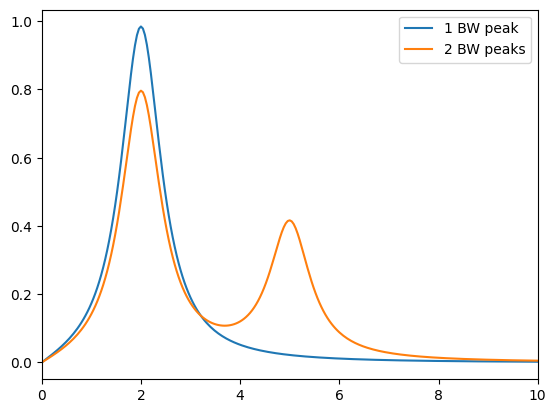

In [191]:
plt.plot(omega,spec1BW,label=r'1 BW peak')
plt.plot(omega,spec2BW, label=r'2 BW peaks')
#plt.plot(omega,spec3BW, label=r'3 BW peaks')

plt.legend()
plt.xlim(0,10)


In [192]:
# Constructing the training data - preparing the discrete kernel 
# Following the paper with grid of Np=25 and Nw=500
epsilon = 1.0e-4 #This epsilon controls momentum close to 0 so that kernel doesnt have zero eigenvalues
p = np.linspace(epsilon,19.2+epsilon,25)
del_pi = p[1]-p[0]

In [193]:
def KL_kernel(Momentum, Omega):
    Momentum = Momentum[:, np.newaxis]  # Reshape Momentum as column to allow broadcasting
    ker = Omega / (Omega**2 + Momentum**2)  # Element-wise division

    return ker / np.pi 
kl_ker = KL_kernel(p,omega)

In [194]:
def KLW_kernel(Momentum, Omega):
    Momentum = Momentum[:, np.newaxis]  # Reshape Momentum as column to allow broadcasting
    ker = Omega**2 / (Omega**2 + Momentum**2)  # Element-wise division

    return ker / np.pi 
klW_ker = KLW_kernel(p,omega)

In [195]:
# Reconstructing the correlator - this function will also be used for the reconstruction in the NN training loop:
def Di(KL, rhoi, delomega):
    # Ensure KL and rhoi are both float32 before performing matmul
    rhoi = tf.cast(rhoi, dtype=tf.float32)
    KL = tf.cast(KL, dtype=tf.float32)
    delomega = tf.cast(delomega, dtype=tf.float32)

    # Matrix multiplication
    dis = tf.matmul(KL, tf.expand_dims(rhoi, axis=-1))  # Matrix multiplication -> [25, 1]
    dis = tf.squeeze(dis, axis=-1)  # Remove the singleton dimension -> [25]
    dis = dis * delomega  
    return dis


In [196]:
##Again Dpi can represent both 1BW or 2BW depending on whether you pass spec1W or spec2W - Be careful!
#Dpi = Di(kl_ker,spec1BW,del_omega)
Dpi = Di(kl_ker,spec1BW,del_omega)

In [207]:
# Adding noise to the correlator, ep_noise can be 1.0e-5,-4,-3
ep_noise = 1.0e-3
custom_std = ep_noise*(Dpi*p)/del_pi  #gaussian width
noisy_Dpi = Dpi + np.random.normal(0,custom_std) #random instance of errors

In [198]:
custom_std

<tf.Tensor: shape=(25,), dtype=float32, numpy=
array([2.93202818e-09, 1.75733967e-05, 2.37761469e-05, 2.41659218e-05,
       2.26007996e-05, 2.06051682e-05, 1.86815741e-05, 1.69679734e-05,
       1.54804111e-05, 1.41976207e-05, 1.30900471e-05, 1.21293615e-05,
       1.12911503e-05, 1.05551735e-05, 9.90491026e-06, 9.32693092e-06,
       8.81029337e-06, 8.34605726e-06, 7.92687115e-06, 7.54664916e-06,
       7.20032449e-06, 6.88365117e-06, 6.59305215e-06, 6.32549018e-06,
       6.07837455e-06], dtype=float32)>

In [208]:
# Setting up the Neural Network
# NN style - Define the neural network architecture one node to 500 - base class
class SpectralNN(tf.keras.Model):
    def __init__(self, num_output_nodes=500, width=64, depth=3):
        super(SpectralNN, self).__init__()
        
        # Create hidden layers
        self.hidden_layers = []
        for _ in range(depth):
            self.hidden_layers.append(tf.keras.layers.Dense(width, activation='elu', use_bias=False))
        
        # Output layer (softplus activation to ensure positive definiteness)
        self.output_layer = tf.keras.layers.Dense(num_output_nodes, activation=tf.keras.activations.softplus, use_bias=False)  # Shape [500]
    
    def call(self, inputs):
        # Forward pass through hidden layers
        x = inputs
        for layer in self.hidden_layers:
            x = layer(x)
        
        # Output layer (representing rho(omega))
        output = self.output_layer(x)  # Shape [500]
        return output

# Compiling the model
# Smoothness regularization term - extra step in paper to make rho smooth
def smoothness_loss(rho):
    diff = rho[:, 1:] - rho[:, :-1]
    return tf.reduce_sum(tf.square(diff))

# L2 regularization term
def l2_regularization(weights):
    return tf.reduce_sum([tf.reduce_sum(tf.square(w)) for w in weights])

# Loss function - depending on whether you pass gauss_width as all ones or the relative errors in 
# the training loop you should get MSE or ChiSE respectively - don't change anything here
def custom_loss(y_true, y_pred,gauss_width):
    # Ensure both y_true and y_pred are of type float32
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)
    gauss_width = tf.cast(gauss_width, dtype=tf.float32)

    chi_squared = tf.square((y_true - y_pred) / gauss_width)
    
    return tf.reduce_mean(chi_squared)  # Chi-squared loss

# Total loss function - main loss computed during the training loop
def total_loss(main_loss, rho, model, lambda_s, lambda_l2):
    # Smoothness loss
    smooth_loss = smoothness_loss(rho)
    
    # L2 loss (regularization on the network weights)
    l2_loss = l2_regularization(model.trainable_weights)
    
    # Total loss = main loss + smoothness regularizer + L2 regularization
    return main_loss + lambda_s * smooth_loss + (lambda_l2 * l2_loss)*0.5

In the cell below, the main training is taking place - feel free to change the following parameters for the experiment:
- lambda_s
- lambda_l2
- epochs both in warm-up and training loops
- learning rates both in warm-up and training loops
- gauss_width between all ones and the relative error on Dp_i

One can also change the number of hidden layers or the width of each layer but care has to be taken in order not to induce syntax errors 

When you makes changes - you only need to re-run the cell below for re-training. 

# New
Either main_loss becomes a vector corresponding to different target_outputs diff noisy_Dpi
The idea is that yPred should fit many correlator instances 
We do this for each epoch - minimise over different targets. After the epoch loop - put a noisy Dpi loop
   

In [209]:
# Preparing the tensor of noise vectors
noisy_dpi_tensor = []
for ii in range(100):
    noisy_Dpi = Dpi + np.random.normal(0,custom_std)
    noisy_dpi_tensor.append(noisy_Dpi)

np.shape(noisy_dpi_tensor)
#print("Shape of target_output:", target_output.shape)

(100, 25)

In [210]:
target_output = tf.convert_to_tensor(noisy_dpi_tensor)
type(target_output.shape[0])


int

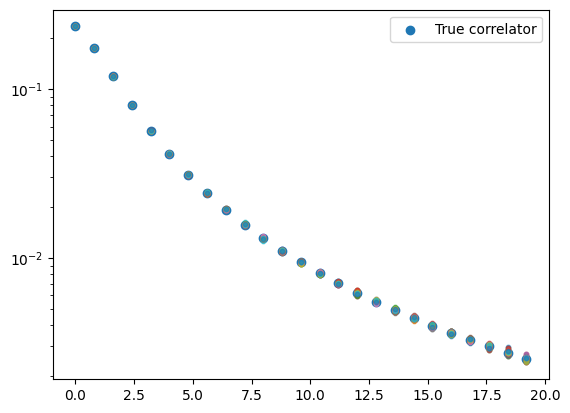

In [211]:
plt.scatter(p,Dpi, label=r'True correlator')
for i in range(50):
    plt.scatter(p, noisy_dpi_tensor[i], s=10, alpha=0.6)

plt.yscale('log')

plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_10Kepochs1BW1e-3.png')
plt.show()

In [218]:
# new custom class iheriting from base class - here structure is added to simple layers above
class CustomTrainingModel(SpectralNN):
    def __init__(self, num_output_nodes, width=64, depth=3, lambda_s=None, lambda_l2=None, kl_ker=None, del_omega=None, gauss_width=None):
        super(CustomTrainingModel, self).__init__(num_output_nodes, width, depth)
        self.lambda_s = lambda_s
        self.lambda_l2 = lambda_l2
        self.kl_ker = klW_ker
        self.del_omega = del_omega
        self.gauss_width = gauss_width
    
    def compute_predictions(self, x):
        return self(x, training=True)
    
    def train_step(self, data):
        x, y = data  # Only unpack x and y (because Keras only passes two values)
        
        with tf.GradientTape() as tape:
            # Forward pass: Compute predictions - Gradient tape keeps track of gradients to allow explicit automatic differentiation
            rhoi_predN = self.compute_predictions(x)
            
            # Reconstruct correlator using external Di function (using stored kl_ker and del_omega)
            y_predN = Di(self.kl_ker, rhoi_predN, self.del_omega)
            
            # Compute custom loss (including smoothness and L2 regularization)
            loss = custom_loss(y, y_predN, gauss_width)
            total_loss_value = total_loss(loss, rhoi_predN, self, self.lambda_s, self.lambda_l2)  # Include smoothness and L2 terms
        
        # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        
        return {"loss": total_loss_value}


# Train the model using the inbuilt `fit`-didn't work beacuse input-output dimensions don't match hence had to write a custom training loop

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dpi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-2
lambda_l2 = 1.0e-4
gauss_width = np.ones(25) #for mean square error
#gauss_width = custom_std #for chi square error

# Initialize the model
model = CustomTrainingModel(num_output_nodes=500, width=64, depth=3, lambda_s=lambda_s, lambda_l2=lambda_l2, kl_ker=klW_ker, del_omega=del_omega, gauss_width=gauss_width)

# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)

epochs=2000
# Custom Training Loop for the smootheness part (called "Warm up loop" in the paper)
for epoch in range(epochs):

    with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
        rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
        y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
        main_loss = 0.0;
        for ii in range(target_output.shape[0]):
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)

        main_loss = main_loss/target_output.shape[0]
        
        total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s, lambda_l2) 
    
    # Compute gradients and update weights
    gradients = tape.gradient(total_loss_value, model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    #print(f"Loss: {total_loss_value.numpy()}")

print("Warm up complete.")

optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
new_epochs = 10000
loss_history = []
for epoch in range(new_epochs):
    #print(f'Resuming Epoch {epoch + 1}/{new_epochs}')
    
    with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
        rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
        y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
        main_loss = 0.0;
        for ii in range(target_output.shape[0]):
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)

        main_loss = main_loss/target_output.shape[0]
  
        total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s=0, lambda_l2=1.0e-8)
    
    # Compute gradients and update weights
    gradients = tape.gradient(total_loss_value, model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    #print(f"Loss: {total_loss_value.numpy()}")
    loss_history.append(total_loss_value.numpy())

print("Training complete for additional epochs.")


Warm up complete.
Training complete for additional epochs.


In [219]:
Final_Dpi = y_pred.numpy().reshape(-1)
#Final_rho = rhoi_pred.numpy().reshape(-1)
Final_rho = rhoi_pred.numpy().reshape(-1)
#Final_rho = Final_rho*omega

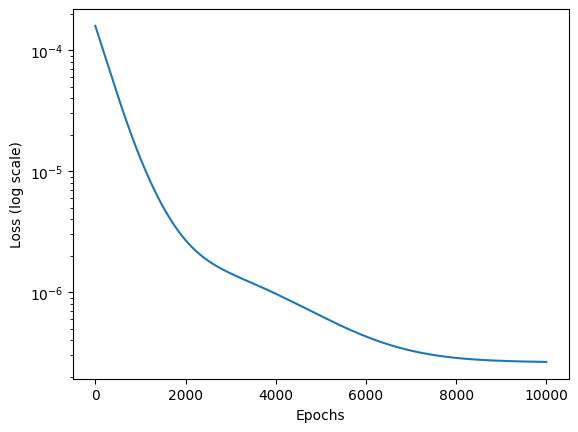

In [220]:
# Plotting loss history
plt.plot(range(new_epochs), loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.yscale('log') 
#plt.title('Training Loss Over Epochs 1BW with mean square')
#plt.savefig('NN_Training_loss_1peak_10K.png')
plt.show()

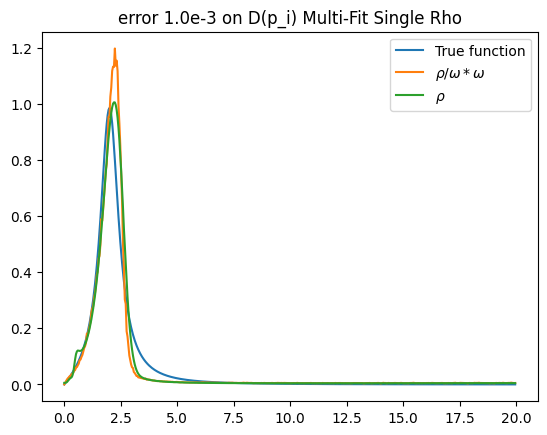

In [227]:
plt.plot(omega,spec1BW, label = r'True function' )
plt.plot(omega,Final_rhoW*omega, label=r'$\rho/\omega * \omega$')
plt.plot(omega,Final_rho, label=r'$\rho$')
plt.title(r'error 1.0e-3 on D(p_i) Multi-Fit Single Rho')
plt.legend()
#plt.savefig('NN_Comparison_RhoByOmega_vs_Rho_MultiFitSingleRho10m3.png')
plt.show()

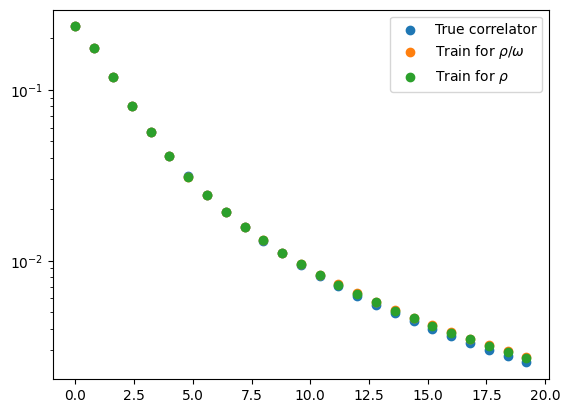

In [226]:
plt.scatter(p,Dpi, label=r'True correlator')
#plt.scatter(p,noisy_Dpi, label=r'Noisy correlator')
plt.scatter(p,Final_DpiW, label=r'Train for $\rho/\omega$')
plt.scatter(p,Final_Dpi, label=r'Train for $\rho$')
#plt.ylim(0.0,0.004)
plt.yscale('log')
#plt.xlim(10,20)

#plt.title('1 BW Peak 5000 epochs error 1e-3')
plt.legend()
#plt.savefig('NN_ComparisonDpi_RhoByOmega_vs_Rho_MultiFitSingleRho10m3.png')
plt.show()

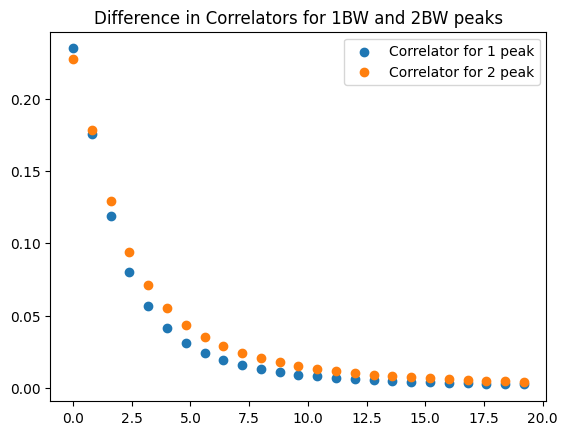

In [417]:
plt.scatter(p,Dpi1, label=r'Correlator for 1 peak')
plt.scatter(p,Dpi2, label=r'Correlator for 2 peak')
plt.title('Difference in Correlators for 1BW and 2BW peaks')
plt.legend()
#plt.savefig('Comparison_Correlators.png')
plt.show()

In [478]:
Ath = tf.ones([25], dtype=tf.float32)
Bth = 2.0*tf.ones([25], dtype=tf.float32)
Cth = 5.0*np.ones(25)


In [479]:
(Ath-Bth)/Cth

<tf.Tensor: shape=(25,), dtype=float32, numpy=
array([-0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2,
       -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2, -0.2,
       -0.2, -0.2, -0.2], dtype=float32)>

In [474]:
Cth[2]

1.0

# Behaviour of the kernal with $\omega$ and $p$.  

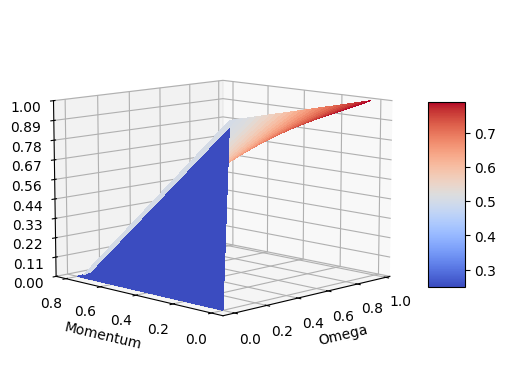

In [57]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data X = Omega, Y = momentum.
X = np.arange(0, 1, 0.04)
Y = np.arange(epsilon, 1+epsilon, del_pi)
X, Y = np.meshgrid(X, Y)
R = X**2 + Y**2
Z = X**2/R

plt.xlabel('Omega')
plt.ylabel('Momentum')
# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(0, 1)
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

ax.view_init(elev=10, azim=225) 

plt.show()

# Bootstrapping
Here we want to generate many spectral functions corresponding to different noisy instances of the correlator and then bootstrap over these samples, which are then to be compared to the other approach.

In [307]:
# new custom class iheriting from base class - here structure is added to simple layers above
class CustomTrainingModel(SpectralNN):
    def __init__(self, num_output_nodes, width=64, depth=3, lambda_s=None, lambda_l2=None, kl_ker=None, del_omega=None, gauss_width=None):
        super(CustomTrainingModel, self).__init__(num_output_nodes, width, depth)
        self.lambda_s = lambda_s
        self.lambda_l2 = lambda_l2
        self.kl_ker = kl_ker
        self.del_omega = del_omega
        self.gauss_width = gauss_width
    
    def compute_predictions(self, x):
        return self(x, training=True)
    
    def train_step(self, data):
        x, y = data  # Only unpack x and y (because Keras only passes two values)
        
        with tf.GradientTape() as tape:
            # Forward pass: Compute predictions - Gradient tape keeps track of gradients to allow explicit automatic differentiation
            rhoi_predN = self.compute_predictions(x)
            
            # Reconstruct correlator using external Di function (using stored kl_ker and del_omega)
            y_predN = Di(self.kl_ker, rhoi_predN, self.del_omega)
            
            # Compute custom loss (including smoothness and L2 regularization)
            loss = custom_loss(y, y_predN, gauss_width)
            total_loss_value = total_loss(loss, rhoi_predN, self, self.lambda_s, self.lambda_l2)  # Include smoothness and L2 terms
        
        # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        
        return {"loss": total_loss_value}

# Create input data and target
constant_input = tf.constant([[1.0]], dtype=tf.float32)  # Constant input node which goes to 500 omegas as the NN structure in paper
target_output = tf.convert_to_tensor(noisy_dpi_tensor)

#the smothness and rigde regularisation coeffcicients - feel free to modify
lambda_s = 1.0e-3
lambda_l2 = 1.0e-6
gauss_width = np.ones(25) #for mean square error
#gauss_width = custom_std #for chi square error

# Initialize the model
# Compile the model - one can also play with learning rate initially it is kept large to scan through a broader manifold of minima and later decreased

In [308]:
#The actual training loops
output_rho_tensor = []
output_Dpi_tensor = []

for ii in range(target_output.shape[0]):
    print('\n',ii,'\n')
    model = CustomTrainingModel(num_output_nodes=500, width=64, depth=3, lambda_s=lambda_s, lambda_l2=lambda_l2, kl_ker=klW_ker, del_omega=del_omega, gauss_width=gauss_width)
    
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    
    epochs=2000
# Custom Training Loop for the smootheness part (called "Warm up loop" in the paper)
    for epoch in range(epochs):

        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)

            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s, lambda_l2) 
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))
    
    #print(f"Loss: {total_loss_value.numpy()}")

    print("Warm up complete.")

    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5) #notice the lower learning rate
    new_epochs = 10000
    loss_history = []
    for epoch in range(new_epochs):
    #print(f'Resuming Epoch {epoch + 1}/{new_epochs}')
    
        with tf.GradientTape() as tape:
        # Forward pass: Compute predictions
            rhoi_pred = model(constant_input) # Shape 500
        
        # Reconstruct correlator using Di function
            y_pred = Di(kl_ker, rhoi_pred, del_omega)  # Shape 25
        
            main_loss += custom_loss(target_output[ii], y_pred, gauss_width)
  
            total_loss_value = total_loss(main_loss, rhoi_pred, model, lambda_s=0, lambda_l2=1.0e-8)
    
    # Compute gradients and update weights
        gradients = tape.gradient(total_loss_value, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    #print(f"Loss: {total_loss_value.numpy()}")
        loss_history.append(total_loss_value.numpy())

    Final_rho_FT = rhoi_pred.numpy().reshape(-1)
    Final_Dpi_FT = y_pred.numpy().reshape(-1)
    output_rho_tensor.append(Final_rho_FT)
    output_Dpi_tensor.append(Final_Dpi_FT)
    print("Training complete for additional epochs.")





 0 

Warm up complete.
Training complete for additional epochs.

 1 

Warm up complete.
Training complete for additional epochs.

 2 

Warm up complete.
Training complete for additional epochs.

 3 

Warm up complete.
Training complete for additional epochs.

 4 

Warm up complete.
Training complete for additional epochs.

 5 

Warm up complete.
Training complete for additional epochs.

 6 

Warm up complete.
Training complete for additional epochs.

 7 

Warm up complete.
Training complete for additional epochs.

 8 

Warm up complete.
Training complete for additional epochs.

 9 

Warm up complete.
Training complete for additional epochs.

 10 

Warm up complete.
Training complete for additional epochs.

 11 

Warm up complete.
Training complete for additional epochs.

 12 

Warm up complete.
Training complete for additional epochs.

 13 

Warm up complete.
Training complete for additional epochs.

 14 

Warm up complete.
Training complete for additional epochs.

 15 

Warm up compl

In [319]:
output_rho = tf.convert_to_tensor(output_rho_tensor,dtype=tf.float32)
output_Dpi = tf.convert_to_tensor(output_Dpi_tensor,dtype=tf.float32)

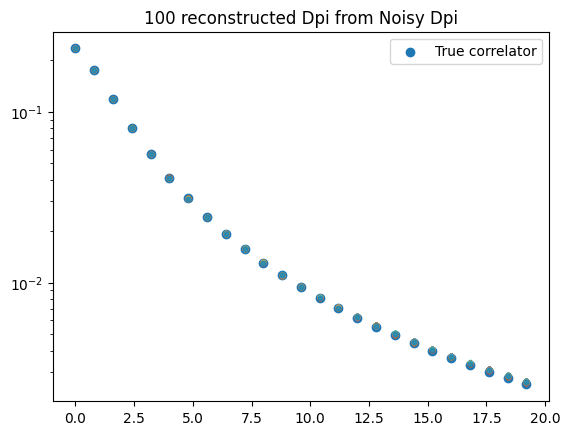

In [332]:
plt.scatter(p,Dpi, label=r'True correlator')
for i in range(100):
    plt.scatter(p, output_Dpi[i], s=10, alpha=0.6)

plt.title(r'100 reconstructed Dpi from Noisy Dpi')
plt.yscale('log')

plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_1BW_100Machines100outputsL21em6.png')
plt.show()

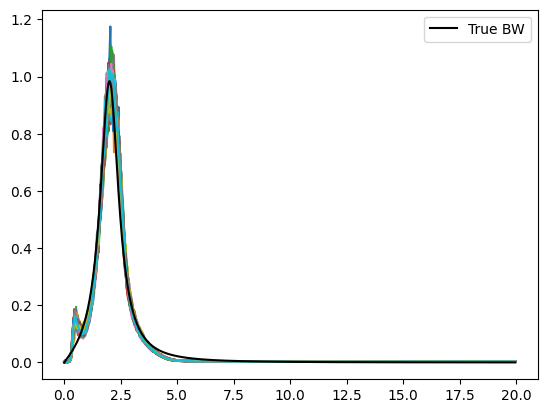

In [322]:
for i in range(100):
    plt.plot(omega, output_rho[i])
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,'-.r', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('Comp_NN_ReconstructedRho_1BW_100Machines100outputsL21em6.png')
plt.show()

In [324]:
#Bootstrap analysis
# Number of bootstrap samples to generate
output_rho_np = output_rho.numpy()
n_bootstrap_samples = 1000
bootstrap_means = []
# Generate bootstrap samples
for _ in range(n_bootstrap_samples):
    
    bootstrap_sample = output_rho_np[np.random.choice(output_rho_np.shape[0], size=output_rho_np.shape[0], replace=True)]
    bootstrap_mean = np.mean(bootstrap_sample, axis=0, keepdims=True)
    bootstrap_means.append(bootstrap_mean)

# Convert to NumPy array for analysis
bootstrap_means = np.array(bootstrap_means)

# Estimate the error (standard deviation of bootstrap means)
bootstrap_error = np.std(bootstrap_means,axis=0)


In [325]:
np.shape(bootstrap_means), np.shape(bootstrap_error), np.shape(MeanMean)
#test = tf.convert_to_tensor(bootstrap_samples)
#tf.shape(test)
#bootstrap_means = np.squeeze(bootstrap_means, axis=1)
#bootstrap_error = bootstrap_error.reshape(500)
#MeanMean = np.mean(bootstrap_means,axis=0)

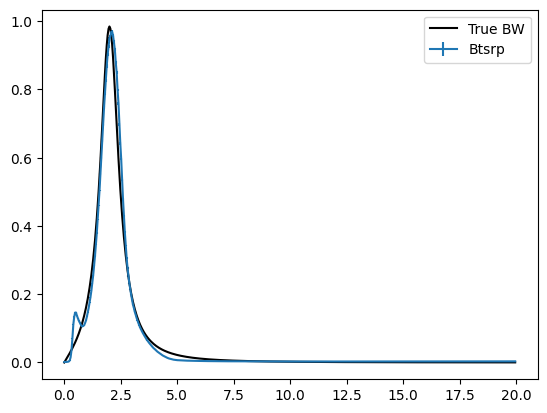

In [331]:
plt.errorbar(omega, MeanMean, yerr=bootstrap_error, label=r'Btsrp')
plt.plot(omega,spec1BW,color='black', label=r'True BW')
#plt.plot(omega,Final_rho,color='red', label=r'Multi Fit Single $\rho$')
plt.legend()
#plt.savefig('NN_ReconstructedCorrelator_10Kepochs1BW1e-3.png')
plt.show()